# Linear Regression From Scratch

Linear Regression models the relationship between the input variables $X$ and the target variable $y$ as

$$
\hat{y} = X\beta
$$

where $\beta$ contains the model parameters.

The parameters are estimated by minimizing the Mean Squared Error (MSE):

$$
J(\beta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Using the Normal Equation, the optimal parameters can be obtained directly as

$$
\beta = (X^TX)^{-1}X^Ty
$$

Model performance is evaluated using the coefficient of determination:

$$
R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}
{\sum (y_i-\bar{y})^2}
$$

In this notebook, Linear Regression is implemented from scratch using NumPy and compared against scikit-learn's implementation.

## 1. Importing liberaries

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 2. Generating synthetic data

The generated data follows $y = 3 + 2x + \epsilon$. 

In [55]:
np.random.seed(42)

n = 100

X = np.random.uniform(0, 10, n)
noise = np.random.normal(0, 2, n)

y = 3 + 2 * X + noise

## 3.Visualizing the data

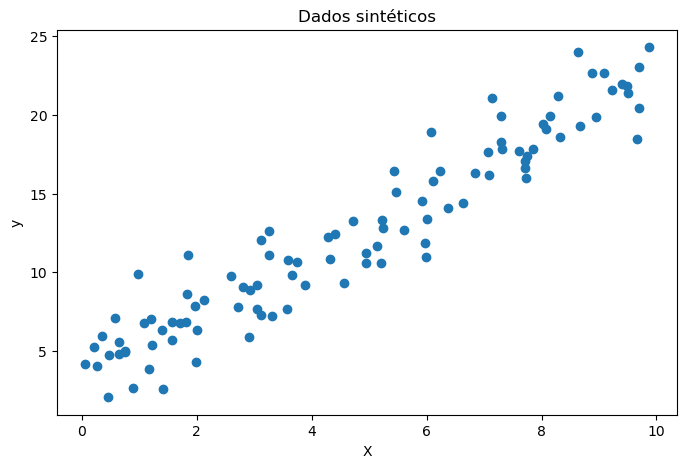

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dados sintéticos")
plt.show()

## 4. Implementing Simple Linear Regression

In [59]:
class SimpleLinearRegression:

    def __init__(self):
        self.intercept_ = None
        self.coef_ = None

    def predict(self, X, beta0=None, beta1=None):

        if beta0 is None:
            beta0 = self.intercept_

        if beta1 is None:
            beta1 = self.coef_

        return beta0 + beta1 * X

    def cost(self, X, y, beta0, beta1):

        total = 0

        for i in range(len(X)):
            pred = self.predict(X[i], beta0, beta1)

            error = (pred - y[i]) ** 2

            total += error

        return total / (2 * len(X))

    def gradient(self, X, y, beta0, beta1):

        # beta0 derivative
        total = 0

        for i in range(len(X)):
            pred = self.predict(X[i], beta0, beta1)
            total += pred - y[i]

        d_beta0 = total / len(X)

        # beta1 derivative
        total = 0

        for i in range(len(X)):
            pred = self.predict(X[i], beta0, beta1)
            total += (pred - y[i]) * X[i]

        d_beta1 = total / len(X)

        return d_beta0, d_beta1

    def fit_gradient_descent(self, X, y, learning_rate, epochs):

        beta0 = 0
        beta1 = 0

        history = []

        for i in range(epochs):

            d_beta0, d_beta1 = self.gradient(
                X, y, beta0, beta1
            )

            beta0 = beta0 - learning_rate * d_beta0
            beta1 = beta1 - learning_rate * d_beta1

            history.append(
                self.cost(X, y, beta0, beta1)
            )

        self.intercept_ = beta0
        self.coef_ = beta1

        return self

    def hessian(self, X):

        X = np.array(X)
        n = len(X)

        X_design = np.column_stack([
            np.ones(n),
            X
        ])

        return (1 / n) * (X_design.T @ X_design)

    def fit_newton(self, X, y, epochs):

        beta0 = 0.0
        beta1 = 0.0

        history = []

        H = self.hessian(X)

        for i in range(epochs):

            d_beta0, d_beta1 = self.gradient(
                X, y, beta0, beta1
            )

            grad = np.array([d_beta0, d_beta1])

            beta = np.array([beta0, beta1])

            beta = beta - np.linalg.solve(H, grad)

            beta0, beta1 = beta

            history.append(
                self.cost(X, y, beta0, beta1)
            )

        self.intercept_ = beta0
        self.coef_ = beta1

        return self

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)
        
        X_design = np.column_stack([
            np.ones(len(X)),
            X
        ])

        beta = (
            np.linalg.inv(X_design.T @ X_design)
            @ X_design.T
            @ y
        )

        self.intercept_ = beta[0]
        self.coef_ = beta[1]

        return self

    def score(self, X, y):

        pred = []

        for i in range(len(X)):
            pred.append(self.predict(X[i]))

        total_pred = 0
        total_mean = 0

        mean_y = np.mean(y)

        for i in range(len(y)):
            total_pred += (y[i] - pred[i]) ** 2
            total_mean += (y[i] - mean_y) ** 2

        return 1 - (total_pred / total_mean)

## 5. Comparing to `scikit-learn`

scikit-learn
Score (R^2):  0.9081437156468248
Intercept: [3.43019232]
Coef: [[1.90804535]]

Own implementation
Score (R^2):  0.9081437156468248
Intercept: 3.4301923150934965
Coef: 1.9080453545753944


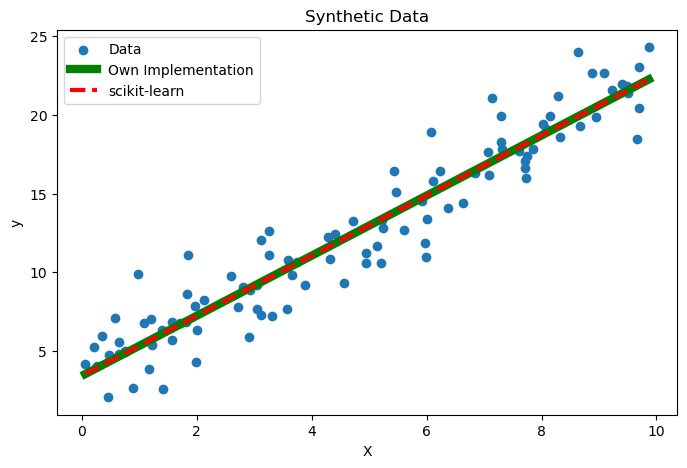

In [60]:
clf_sklearn = LinearRegression()
clf_implementation = SimpleLinearRegression()

clf_sklearn.fit(X.reshape(-1, 1), y.reshape(-1, 1))
clf_implementation.fit(X, y)

print("scikit-learn")
print("Score (R^2): ", clf_sklearn.score(X.reshape(-1, 1), y.reshape(-1, 1)))
print("Intercept:", clf_sklearn.intercept_)
print("Coef:", clf_sklearn.coef_)

print("\nOwn implementation")
print("Score (R^2): ", clf_implementation.score(X, y))
print("Intercept:", clf_implementation.intercept_)
print("Coef:", clf_implementation.coef_)

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Data")

x_line = np.linspace(X.min(), X.max(), 100)

y_sklearn = (
    clf_sklearn.intercept_[0]
    + clf_sklearn.coef_[0][0] * x_line
)

y_implementation = (
    clf_implementation.intercept_
    + clf_implementation.coef_ * x_line
)

plt.plot(
    x_line,
    y_implementation,
    linewidth=6,
    label="Own Implementation",
    color="g"
)

plt.plot(
    x_line,
    y_sklearn,
    linestyle="--",
    label="scikit-learn",
    color="r",
    linewidth=3,
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.legend()

plt.show()

## 6. Implementing Multiple Linear Regression

In [61]:
class _LinearRegression:

    def __init__(self):
        self.intercept_ = None
        self.coef_ = None

    def predict(self, X, beta=None):

        if beta is None:
            self.intercept_ = beta[0]
            self.coef_ = beta[1:]
            
        X = np.asarray(X)

        return X @ self.coef_ + self.intercept_

    def cost(self, X, y, beta=None):
       
        X = np.asarray(X)
        y = np.asarray(y)
    
        pred = self.predict(X, beta)
    
        return np.sum((pred - y) ** 2) / (2 * len(X))
       
    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        X_design = np.column_stack([
            np.ones(len(X)),
            X
        ])

        beta = (
            np.linalg.inv(X_design.T @ X_design)
            @ X_design.T
            @ y
        )

        self.intercept_ = beta[0]
        self.coef_ = beta[1:]

        return self

    def score(self, X, y):

        y = np.asarray(y)
    
        pred = self.predict(X)
    
        ss_res = np.sum((y - pred) ** 2)
    
        ss_tot = np.sum((y - np.mean(y)) ** 2)
    
        return 1 - (ss_res / ss_tot)

## 7. Generating synthetic data with multiple features

In [62]:
np.random.seed(42)

n = 100

X = np.column_stack([
    np.random.uniform(0, 10, n),
    np.random.uniform(0, 20, n)
])

intercept = 3
coef = np.array([2, 4])

noise = np.random.normal(0, 2, n)

y = X @ coef + intercept + noise

## 8. Comparing to `scikit-learn` (multiple Linear Regression)

In [63]:
clf_sklearn = LinearRegression()
clf_implementation = _LinearRegression()

clf_sklearn.fit(X, y)
clf_implementation.fit(X, y)

print("scikit-learn")
print("Score (R^2): ", clf_sklearn.score(X, y))
print("Intercept:", clf_sklearn.intercept_)
print("Coef:", clf_sklearn.coef_)

print("\nOwn implementation")
print("Score (R^2): ", clf_implementation.score(X, y))
print("Intercept:", clf_implementation.intercept_)
print("Coef:", clf_implementation.coef_)

scikit-learn
Score (R^2):  0.9936031674939828
Intercept: 2.8212200729001538
Coef: [1.93165494 4.07193114]

Own implementation


TypeError: 'NoneType' object is not subscriptable